In [1]:
import importlib
#importlib.reload(i24_motion_carla_cosim)
import i24_motion_carla_cosim
import matplotlib.pyplot as plt

In [8]:
cosim = i24_motion_carla_cosim.I24MotionCARLACoSim(1, -2, 1669812000+50, 1000)

RuntimeError: Query interrupted

In [ ]:
ghosts = cosim.getGhostData()

In [ ]:
visible = cosim.getVisibleData()

In [ ]:
hero_state = cosim.getHeroData()

In [ ]:
cosim.tick(hero_state, visible)

In [ ]:
visible[-3][58907]

{'id': 58907,
 'class': 4,
 'length': 22.72879870605469,
 'width': 3.0518698219299316,
 'time': 1669812050.0000005,
 's': 1121.9994156403754,
 't': -10.057062908000022,
 'velocity': 29.763865550972522,
 'lane': -3}

In [ ]:
cosim.current_timestamp

1669812050.03

In [ ]:
cosim.getCurrentBehindGhostWindow()

(1669812050.03, 1669812050.28, 787.024044909006, 837.024044909006)

In [ ]:
cosim.getCurrentAheadGhostWindow()

(1669812050.03, 1669812050.28, 1137.024044909006, 1187.024044909006)

In [ ]:
cosim.getHeroData()

{'id': 59002,
 'class': 0,
 'length': 5.353098834228516,
 'width': 1.6105653556823731,
 'time': 1669812050.03,
 's': 987.024044909006,
 't': -4.452539498231484,
 'velocity': 35.3289773877256,
 'lane': -2}

In [ ]:
for i in range(1000):
    print(i)
    hero_state = cosim.getHeroData()
    visible = cosim.getVisibleData()
    cosim.tick(hero_state, visible)

0
Checking behind!
Checking behind!
1
Checking behind!
Checking behind!
2
Checking behind!
Checking behind!
3
Checking behind!
Checking behind!
4
Checking behind!
Checking behind!
5
Checking behind!
Checking behind!
6
Checking behind!
Checking behind!
7
Checking behind!
8
Checking behind!
9
Checking behind!
10
Checking behind!
11
Checking behind!
12
Checking behind!
13
Checking behind!
Checking behind!
14
Checking behind!
Checking behind!
15
Checking behind!
Checking behind!
Checking behind!
16
Checking behind!
Checking behind!
17
Checking behind!
Checking behind!
18
Checking behind!
Checking behind!
19
Checking behind!
Checking behind!
20
Checking behind!
Checking behind!
21
Checking behind!
Checking behind!
22
Checking behind!
Checking behind!
23
Checking behind!
Checking behind!
24
Checking behind!
Checking behind!
25
Checking behind!
Checking behind!
Checking behind!
26
Checking behind!
Checking behind!
Checking behind!
27
Checking behind!
Checking behind!
Checking behind!
28
Check

In [ ]:
cosim.getGhostData()

{'behind': {-1: {},
  -2: {61609: {'id': 61609,
    'class': 0,
    'length': 5.174113053894044,
    'width': 1.5926968242645265,
    'time': 1669812100.0,
    's': 817.9382087220257,
    't': -4.248620744316022,
    'velocity': 34.37166200021395,
    'lane': -2}},
  -3: {},
  -4: {61529: {'id': 61529,
    'class': 1,
    'length': 4.700773099136353,
    'width': 1.7397997638702394,
    'time': 1669812100.0,
    's': 834.1501555614858,
    't': -12.806899494472821,
    'velocity': 26.319941593990578,
    'lane': -4}}},
 'ahead': {-1: {},
  -2: {61507: {'id': 61507,
    'class': 2,
    'length': 5.80240556602478,
    'width': 2.075187504386902,
    'time': 1669812099.98,
    's': 1153.3633839858621,
    't': -5.742207977817188,
    'velocity': 35.65363602722032,
    'lane': -2}},
  -3: {},
  -4: {}}}

In [ ]:
len(cosim.getVisibleData()[-4])

6

In [ ]:
cosim.getVisibleIdsFlat()

[58999,
 58965,
 59178,
 58976,
 59143,
 59188,
 59041,
 59158,
 59115,
 59033,
 59214,
 59258,
 59187,
 59700,
 59077,
 58943,
 58944,
 58907,
 59389,
 58985,
 58934,
 58929,
 59180,
 58925]

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from moviepy.video.VideoClip import VideoClip

def get_numpy_array_from_figure(fig):
    # Draw the canvas, cache the renderer
    fig.canvas.draw()
    
    # Get the RGBA buffer from the figure
    w, h = fig.canvas.get_width_height()
    # Use tostring_rgb() for RGB or tostring_argb() for ARGB (need to roll axis)
    buf = np.frombuffer(bytes(fig.canvas.get_renderer().buffer_rgba()), dtype='uint8')
    
    # Reshape the buffer to a 3D array (H, W, 3)
    image_np = buf.reshape(h, w, 4)
    image_np = image_np[:, :, :3]
    return image_np

def compute_world_bounds(cosim, padding=0.0):
    return (cosim.hero_state["s"] - cosim.visible_window - cosim.ghost_window - padding, cosim.hero_state["s"] + cosim.visible_window + cosim.ghost_window + padding, -50, 0)

def bbox_corners_2d(vehicle_data):
    cx, cy = vehicle_data["s"], vehicle_data["t"]
    length, width = vehicle_data["length"], vehicle_data["width"] / 2.0
    return np.array([[cx + length, cy + width], [cx + length, cy - width], [cx, cy - width], [cx, cy + width]])


def make_video_from_snapshots(cosim, snapshots, bounds, fps=20, out_path="carla_bboxes.mp4"):

    duration = len(snapshots) / fps

    def make_frame(t):
        frame_idx = int(t * fps)
        frame_idx = min(frame_idx, len(snapshots) - 1)
        frame = snapshots[frame_idx]
        xmin, xmax, ymin, ymax = bounds[frame_idx]

        fig, ax = plt.subplots(figsize=(18, 6))
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(f"Frame {frame_idx}")

        # Draw each vehicle bbox
        for car in frame:
            corners = bbox_corners_2d(car)
            poly = plt.Polygon(corners, fill=False, linewidth=1.0)
            ax.add_patch(poly)
            ax.text(
                car["s"] + 0.5, car["t"],
                str(car["id"]),
                color="red",
                fontsize=8,
                ha="center", va="center",
            )

        # Optional: draw axes labels / grid
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.grid(True, linewidth=0.2)

        # Plot ghost and visible regions
        #Behind ghost region
        ax.axvspan(xmin, xmin + cosim.ghost_window, ymin=0, ymax=1, color='yellow', alpha=0.7)

        #Visible region
        ax.axvspan(xmin + cosim.ghost_window, xmax - cosim.ghost_window, ymin=0, ymax=1, color='green', alpha=0.7)

        #Ahead ghost region
        ax.axvspan(xmax - cosim.ghost_window, xmax, ymin=0, ymax=1, color='yellow', alpha=0.7)

        fig.tight_layout()
        image = get_numpy_array_from_figure(fig)
        plt.close(fig)
        return image

    clip = VideoClip(make_frame, duration=duration)
    clip.write_videofile(out_path, fps=fps, codec="libx264")

def updateVisibleAndHeroVehicleUsingConstantVelocity(hero_state, visible_state, velocity=0.0):
    hero_state["s"] += (velocity * 0.05)
    for lane in visible_state:
        for id in visible_state[lane]:
            visible_state[lane][id]["s"] += (velocity * 0.05)

def tickAndGetVisibleAndGhostSnapshots(cosim):
    vehicles = []
    hero_state = cosim.getHeroData()
    visible_state = cosim.getVisibleData()
    ghost_state = cosim.getGhostData()
    bounds = compute_world_bounds(cosim)
    updateVisibleAndHeroVehicleUsingConstantVelocity(hero_state, visible_state)
    cosim.tick(hero_state, visible_state)
    vehicles.append(hero_state)
    for lane in visible_state:
        for id in visible_state[lane]:
            vehicles.append(visible_state[lane][id])

    for position in ghost_state:
        for lane in ghost_state[position]:
            for id in ghost_state[position][lane]:
                vehicles.append(ghost_state[position][lane][id])
    return vehicles, bounds

def collectXTimestepsFromCosim(cosim, steps=200):
    result = []
    bounds = []
    for i in range(steps):
        result_current, bounds_current = tickAndGetVisibleAndGhostSnapshots(cosim)
        result.append(result_current)
        bounds.append(bounds_current)
        print(i)
    print(bounds)
    return result, bounds

if __name__ == "__main__":
    cosim = i24_motion_carla_cosim.I24MotionCARLACoSim(1, -2, 1669812000+50, 1000)
    snapshots, bounds = collectXTimestepsFromCosim(cosim)

    # 2) Make top-down bbox video
    make_video_from_snapshots(cosim, snapshots, bounds, fps=20, out_path="carla_bboxes_patched_constant_speed_zero.mp4")


Checking behind!
Checking behind!
Candidate visible {'id': 59303, 'class': 0, 'length': 4.792190984853109, 'width': 1.6966695476531983, 'time': 1669812049.98, 's': 824.2315954544042, 't': -5.290985833909379, 'velocity': 31.698617813893744, 'lane': -2} which is a ghost has a projected 825.8165248335911 position with this window (1669812049.93, 1669812050.1299999, 837.024044909006, 1137.024044909006)
Candidate visible {'id': 59365, 'class': 1, 'length': 7.584205237197876, 'width': 2.377955873308182, 'time': 1669812049.98, 's': 812.3892081023025, 't': -9.377584804669416, 'velocity': 27.702898053661585, 'lane': -3} which is a ghost has a projected 813.7743516840085 position with this window (1669812049.93, 1669812050.1299999, 837.024044909006, 1137.024044909006)
Checking behind!
Checking behind!
0
Candidate visible {'id': 59303, 'class': 0, 'length': 4.792190984853109, 'width': 1.6966695476531983, 'time': 1669812050.03, 's': 825.8170677434991, 't': -5.279793689022603, 'velocity': 31.709476

MoviePy - Done !
MoviePy - video ready carla_bboxes_patched_constant_speed_zero.mp4


In [21]:
cosim.getCurrentVisibleWindow()

(1669812059.8799906, 1669812060.0799904, 1137.024044909006, 1437.024044909006)

In [24]:
cosim.ghost_state

{'behind': {-1: {},
  -2: {},
  -3: {59365: {'id': 59365,
    'class': 1,
    'length': 7.584205237197876,
    'width': 2.377955873308182,
    'time': 1669812059.9799905,
    's': 1109.4115620955463,
    't': -9.830737832814098,
    'velocity': 31.653480446918742,
    'lane': -3}},
  -4: {59794: {'id': 59794,
    'class': 0,
    'length': 5.108880601501465,
    'width': 1.8449174755096436,
    'time': 1669812059.9799905,
    's': 1128.9541949216934,
    't': -12.853405123360153,
    'velocity': 30.52882231229695,
    'lane': -4},
   59479: {'id': 59479,
    'class': 0,
    'length': 4.747880688858032,
    'width': 1.5870446983337403,
    'time': 1669812059.9799905,
    's': 1087.5536260636713,
    't': -13.257725577388074,
    'velocity': 28.68243486819922,
    'lane': -4}}},
 'ahead': {-1: {59522: {'id': 59522,
    'class': 0,
    'length': 5.111075567190988,
    'width': 1.7362438139779228,
    'time': 1669812059.9799905,
    's': 1438.0099756629681,
    't': -3.0215235589685565,
   

# Plot from CARLA

In [43]:
import pandas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def plotTimeDiagramFromCSV(path, road, lane, road_name):
    data = pandas.read_csv(path)
    data_filtered = data[(data["road_id"] == road)]
    if lane is not None:
        data_filtered = data[(data["lane_id"] == lane)]
    unique_ids = list(data_filtered["vehicle_id"].unique())
    fig, ax = plt.subplots(figsize=(16, 12))
    for unique in unique_ids:
        data_unique = data_filtered[data_filtered["vehicle_id"] == unique]
        if data_unique["hero_status"].max() >= 0.5:
            ax.plot(data_unique["simulation_time"], data_unique["s"], linewidth=1.0, color='red', label="Hero Vehicle")
        else:
            ax.plot(data_unique["simulation_time"], data_unique["s"], linewidth=1.0, alpha=0.25, color='black', label="Visible Vehicle")
    ax.set_title(f"{road_name} Road")
    ax.legend(handles=[
        mpatches.Patch(color='red', label="Hero Vehicle"),
        mpatches.Patch(color='black', label="Visible Vehicle")
    ])
    fig.show()


/tmp/ipykernel_1681979/3367305747.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


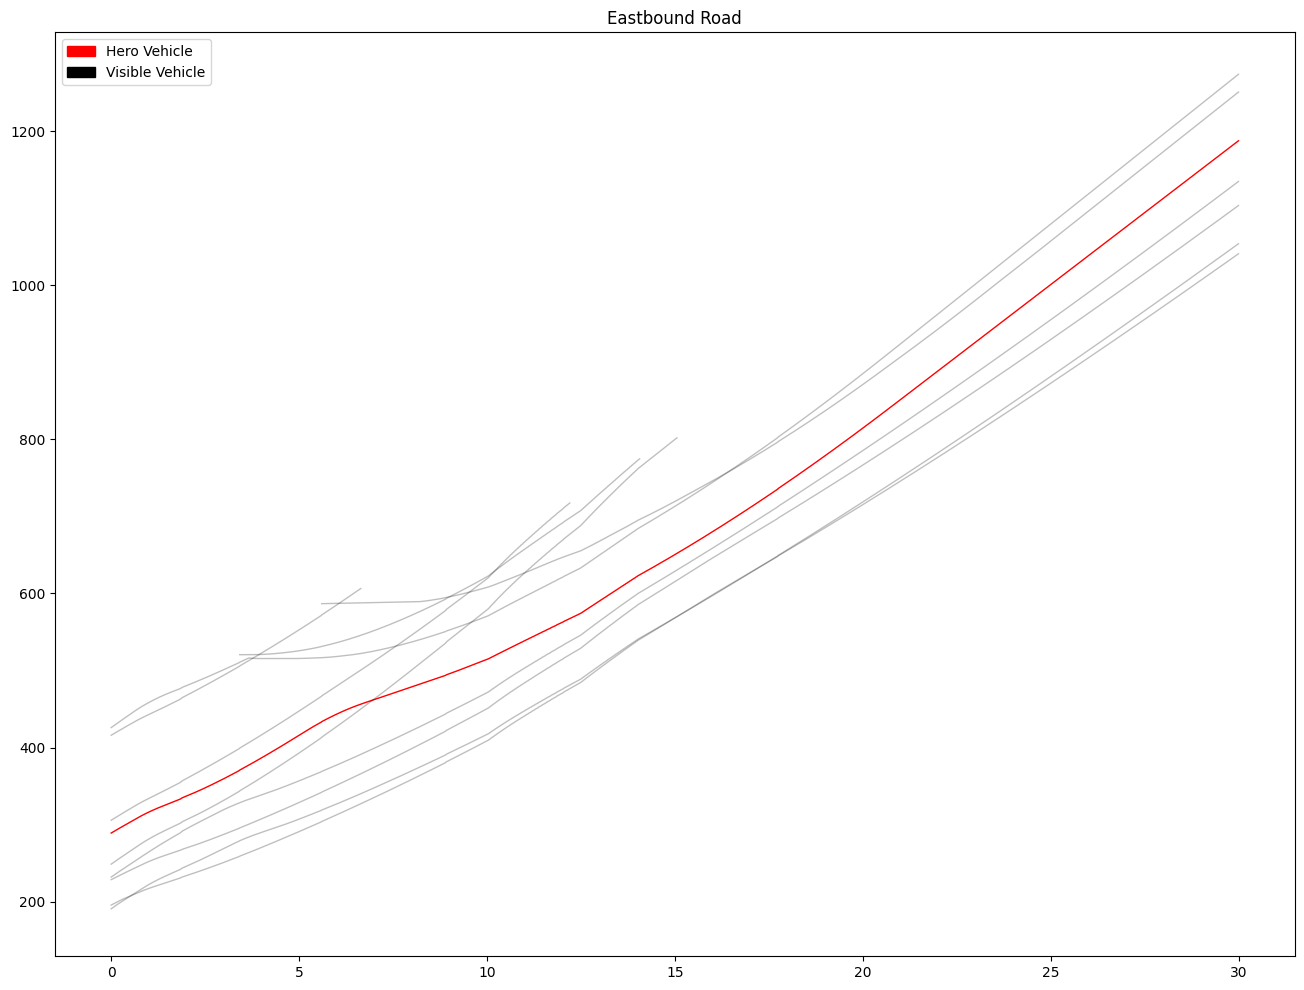

In [45]:
plotTimeDiagramFromCSV("result_new_road_1_lane_2.csv", 1, None, "Eastbound")

/tmp/ipykernel_1681979/3367305747.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


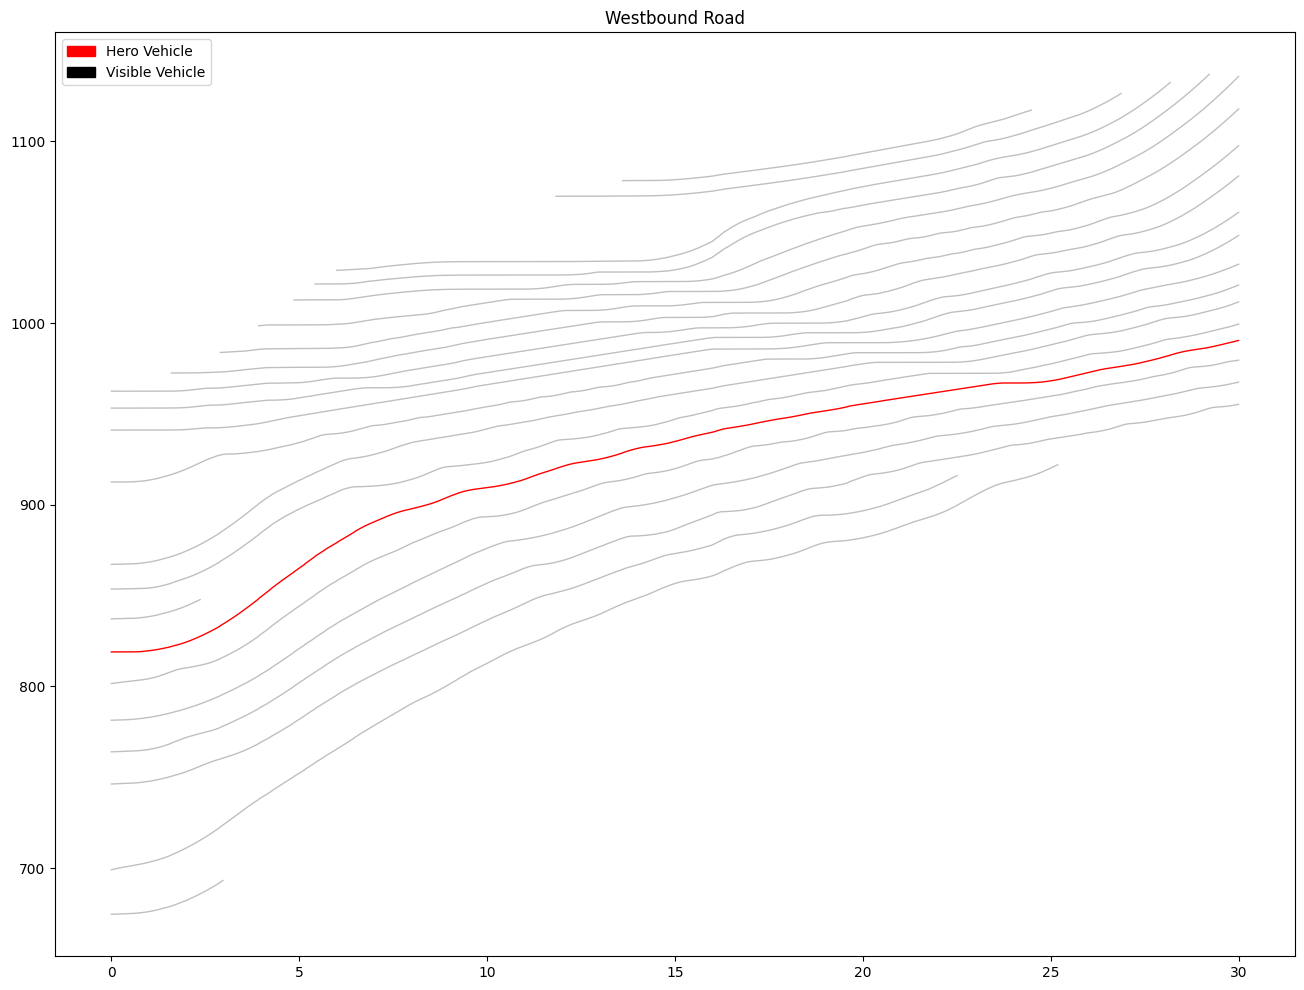

In [46]:
plotTimeDiagramFromCSV("result_new_road_2_lane_1.csv", 2, -1, "Westbound")

# Plot ground truth from the real world

{-1:               time              x          y     length     width    height  \
0     1.669812e+09  319961.802039 -16.654217  15.455015  5.496706  4.479442   
1     1.669812e+09  320045.361578 -21.802738  18.000353  5.868385  4.998035   
2     1.669812e+09  320363.147816 -17.121089  14.369100  5.672677  4.546623   
3     1.669812e+09  323020.744281 -16.553674  16.646091  5.498281  4.693992   
4     1.669812e+09  323395.991736 -18.382330  19.376796  6.333003  5.204947   
...            ...            ...        ...        ...       ...       ...   
8009  1.669812e+09  323753.836458 -20.153127  15.991202  5.609011  4.473061   
8010  1.669812e+09  323842.268333 -16.277567  17.629786  5.690984  5.124253   
8011  1.669812e+09  320864.069146 -13.192450  20.257323  6.645490  5.259293   
8012  1.669812e+09  320976.837031 -12.812608  15.280420  5.681881  4.421567   
8013  1.669812e+09  321400.918238 -13.241484  19.480742  5.883348  4.780273   

      class     id            s         t  
0 

/tmp/ipykernel_1681979/602443161.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


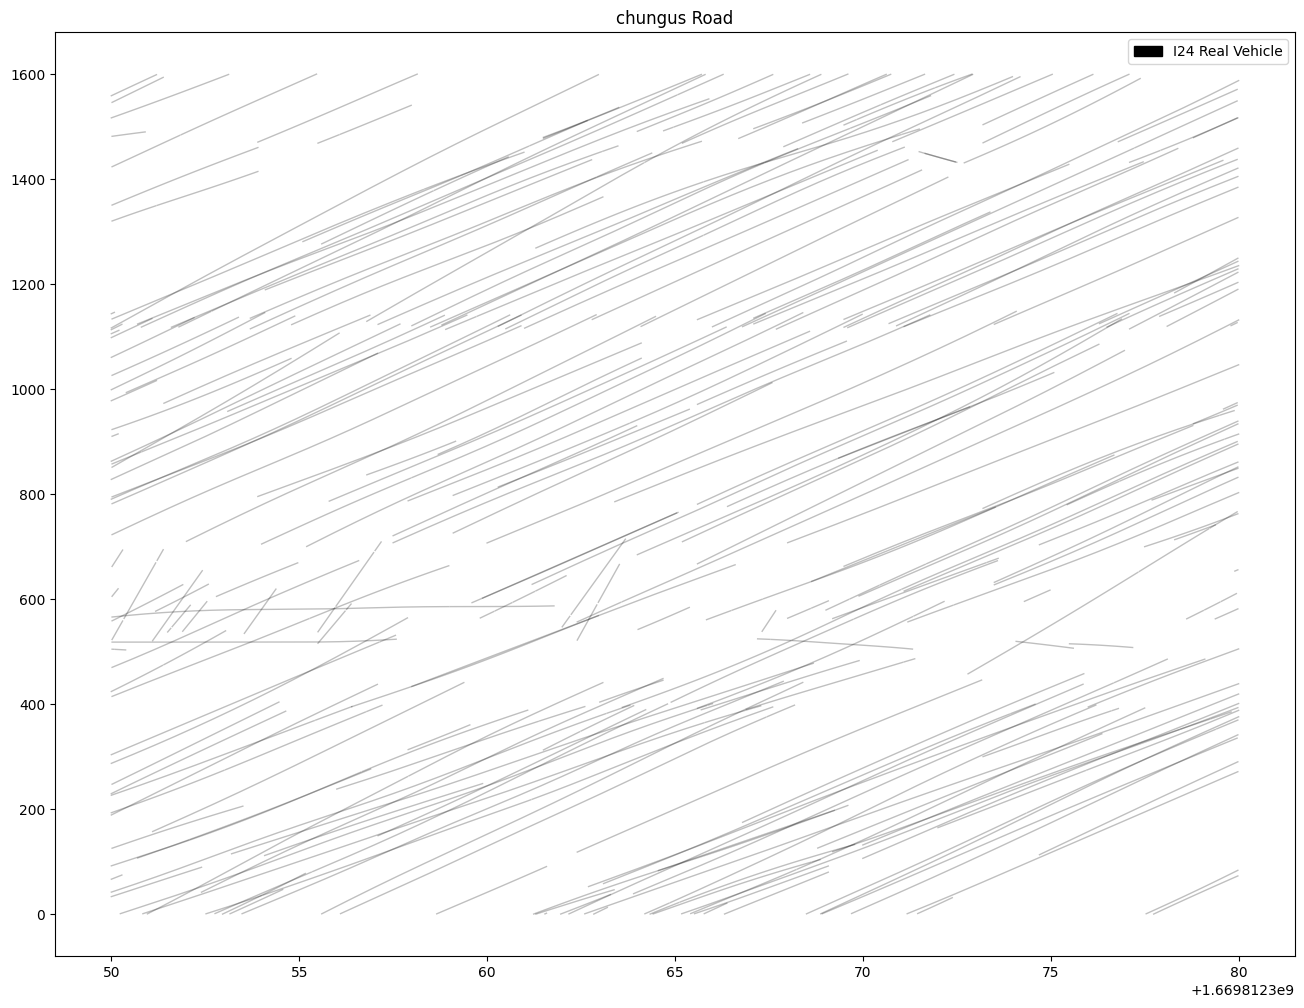

In [73]:
import i24_motion_data
import pandas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def plotTimeDiagramFromI24DataOnly(start_timestamp, road, selected_lane, road_name):
    source_data = i24_motion_data.I24MotionData(road, start_timestamp, start_timestamp + 30.0, -1600, 1600)
    edie_box_sample = source_data.queryEdieBoxSubset(start_timestamp, start_timestamp+30.0, 0, 1600)

    print(edie_box_sample)
    fig, ax = plt.subplots(figsize=(16, 12))
    for lane in edie_box_sample:
        edie_box_sample_lane = edie_box_sample[lane]
        unique_values = edie_box_sample_lane["id"].unique()
        for entry_id in unique_values:
            entry = edie_box_sample_lane[edie_box_sample_lane["id"] == entry_id]
            ax.plot(entry["time"], entry["s"], linewidth=1.0, alpha=0.25, color='black', label="I24 Real Vehicle")
    ax.set_title(f"{road_name} Road")
    ax.legend(handles=[
        mpatches.Patch(color='black', label="I24 Real Vehicle")
    ])
    fig.show()
plotTimeDiagramFromI24DataOnly(1669812000+350, 1, -1, "chungus")


In [ ]:
import i24_motion_data
import pandas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def plotTimeDiagramFromI24Data(csv_path, start_timestamp, road, selected_lane, road_name):
    sim_data = pandas.read_csv(csv_path)
    total_timestep = float(sim_data["simulation_time"].max())
    min_s = float(sim_data[sim_data["hero_status"] == 1]["s"].min())
    max_s = float(sim_data[sim_data["hero_status"] == 1]["s"].max())
    source_data = i24_motion_data.I24MotionData(road, 1669812000.0 , 1669812600, -1600, 1600)
    print(start_timestamp, start_timestamp+total_timestep, min_s, max_s)
    edie_box_sample = source_data.queryEdieBoxSubset(start_timestamp, start_timestamp+total_timestep, min_s, max_s)
    sim_data_filtered = sim_data[(sim_data["road_id"] == road)]
    if selected_lane is not None:
        sim_data_filtered = sim_data[(sim_data["lane_id"] == selected_lane)]
    unique_ids = list(sim_data_filtered["vehicle_id"].unique())
    fig, ax = plt.subplots(figsize=(16, 12))
    for unique in unique_ids:
        data_unique = sim_data_filtered[sim_data_filtered["vehicle_id"] == unique]
        if data_unique["hero_status"].max() >= 0.5:
            ax.plot(data_unique["simulation_time"], data_unique["s"], linewidth=1.0, color='red', label="Hero Vehicle")
    print(edie_box_sample)
    for lane in edie_box_sample:
        if (selected_lane is not None) and (lane != selected_lane):
            continue
        edie_box_sample_lane = edie_box_sample[lane]
        unique_values = edie_box_sample_lane["id"].unique()
        for entry_id in unique_values:
            entry = edie_box_sample_lane[edie_box_sample_lane["id"] == entry_id]
            ax.plot(entry["time"] - start_timestamp, entry["s"], linewidth=1.0, alpha=0.25, color='black', label="I24 Real Vehicle")
    ax.set_title(f"{road_name} Road")
    ax.legend(handles=[
        mpatches.Patch(color='red', label="Hero Vehicle"),
        mpatches.Patch(color='black', label="I24 Real Vehicle")
    ])
    fig.show()

In [80]:
plotTimeDiagramFromI24Data("result_new_road_1_lane_2.csv", 1669812000+350, 1, None, "Eastbound")

1669812350 1669812379.99 288.99868774414057 1187.7953491210938


UnboundLocalError: local variable 'lane' referenced before assignment

1669812350 1669812379.99 818.9964971542358 990.4073257446288
{-1:                time              x          y     length     width    height  \
0      1.669812e+09  322466.824660  16.400031  18.563991  6.528321  6.452062   
1      1.669812e+09  322421.851233  13.302495  15.525469  5.517118  5.340333   
2      1.669812e+09  322179.438037  15.405514  16.549335  6.014914  5.886569   
3      1.669812e+09  322138.286541  16.028398  15.970308  5.566500  4.573600   
4      1.669812e+09  322519.151911  15.855271  15.464357  5.766191  4.608102   
...             ...            ...        ...        ...       ...       ...   
10355  1.669812e+09  322126.396685  15.875246  15.081778  5.591107  5.161674   
10356  1.669812e+09  322539.988287  16.100362  14.118703  5.421010  4.442300   
10357  1.669812e+09  322475.812857  16.145153  15.577013  6.114614  6.054211   
10358  1.669812e+09  322396.975946  15.749830  14.951822  5.619365  5.346904   
10359  1.669812e+09  322075.356205  19.126602  15.5505

/tmp/ipykernel_1681979/330575896.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


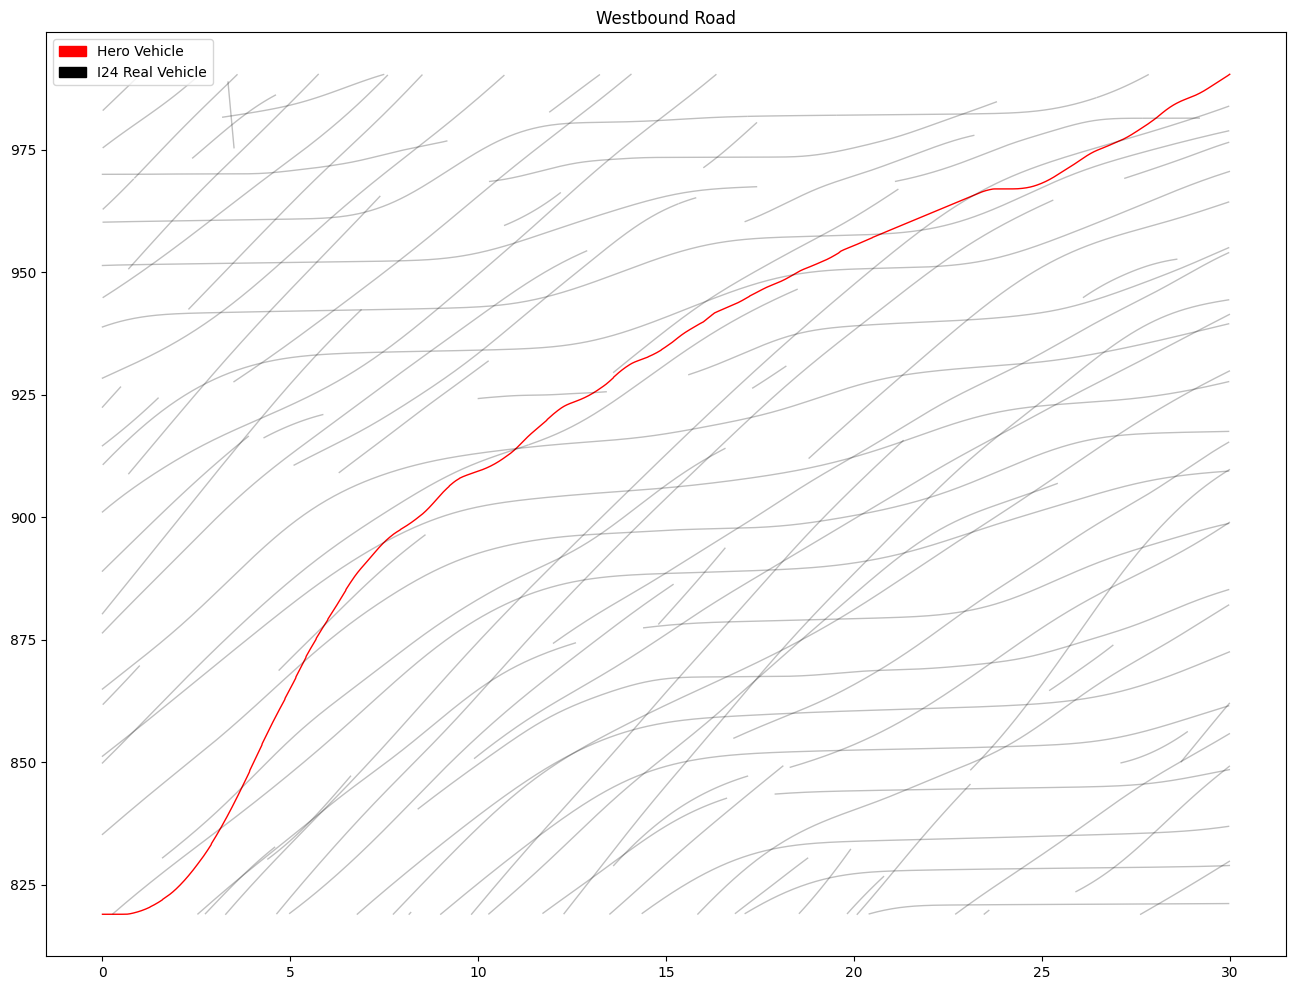

In [ ]:
plotTimeDiagramFromI24Data("result_new_road_2_lane_1.csv", 1669812000+350, 2, None, "Westbound")